In [1]:
from dataclasses import dataclass
import math
import random
import copy
import collections
import numpy as np
import os
from pathlib import Path
from PIL import Image
from PIL.ExifTags import TAGS
from collections import Counter
import tqdm
import re
import torch
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
import time
from datetime import datetime
import exiftool
import enum
import torchvision
import pickle
import itertools
from collections import Counter
import itertools


In [2]:
DATA_ROOT = '/home/slavik/e202602_eclipse/data'
BRIGHTNESS_MIN = 0.0
BRIGHTNESS_MAX = 1.0
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [3]:
class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

In [4]:

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None    # (center_i, center_j, radius) in pixels
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None



In [5]:
with open('/home/slavik/tmp/eda00.pkl', mode='rb') as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)

exp=0.00025: images=6, triplets=20
exp=0.00050: images=7, triplets=35
exp=0.00100: images=4, triplets=4
exp=0.00156: images=4, triplets=4
exp=0.00200: images=4, triplets=4
exp=0.00400: images=4, triplets=4
exp=0.00800: images=4, triplets=4
exp=0.01667: images=5, triplets=10
exp=0.02500: images=5, triplets=10
exp=0.03333: images=5, triplets=10
exp=0.05000: images=4, triplets=4
exp=0.06667: images=5, triplets=10
exp=0.12500: images=5, triplets=10
exp=0.25000: images=4, triplets=4
exp=0.50000: images=5, triplets=10
exp=1.00000: images=9, triplets=84
exp=2.00000: images=4, triplets=4
----------------- pruning ------------------
exp=0.00025: images=6, triplets=20
exp=0.00050: images=7, triplets=35
exp=0.00100: images=4, triplets=4
exp=0.00156: images=4, triplets=4
exp=0.00200: images=4, triplets=4
exp=0.00400: images=4, triplets=4
exp=0.00800: images=4, triplets=4
exp=0.01667: images=5, triplets=10
exp=0.02500: images=5, triplets=10
exp=0.03333: images=5, triplets=10
exp=0.05000: images=4, 

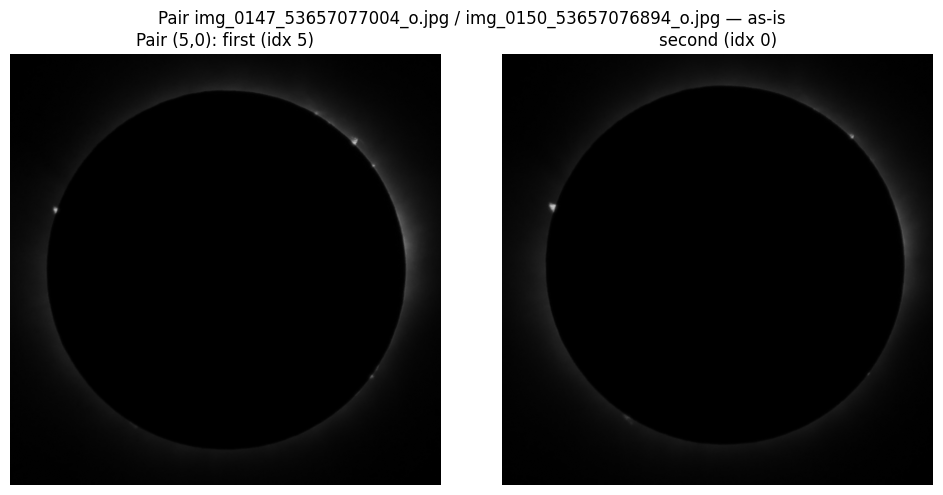

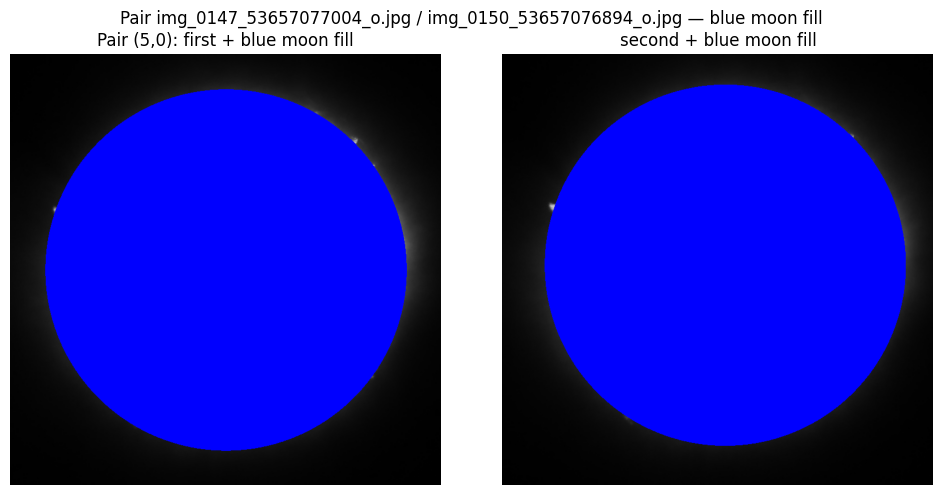

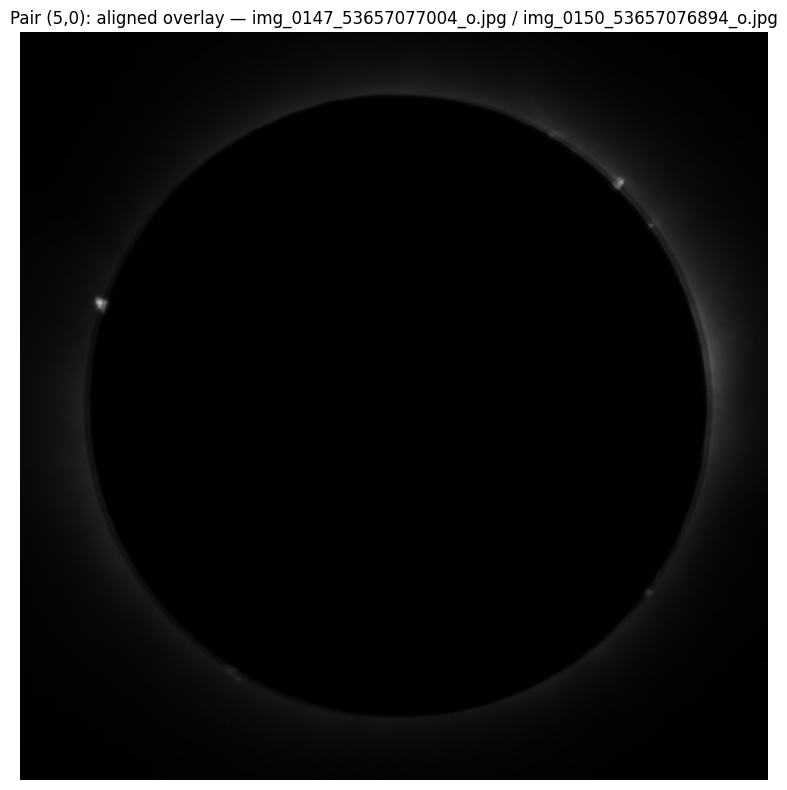

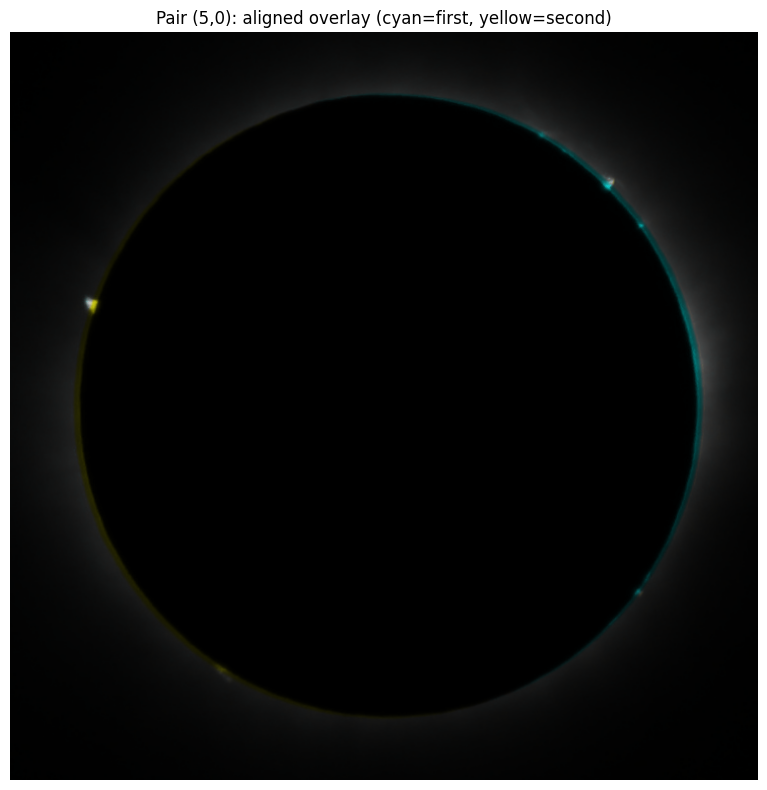

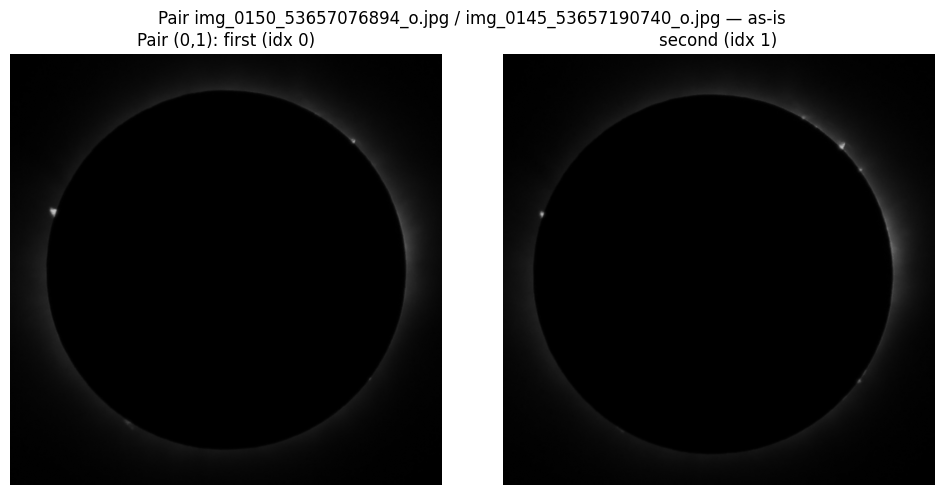

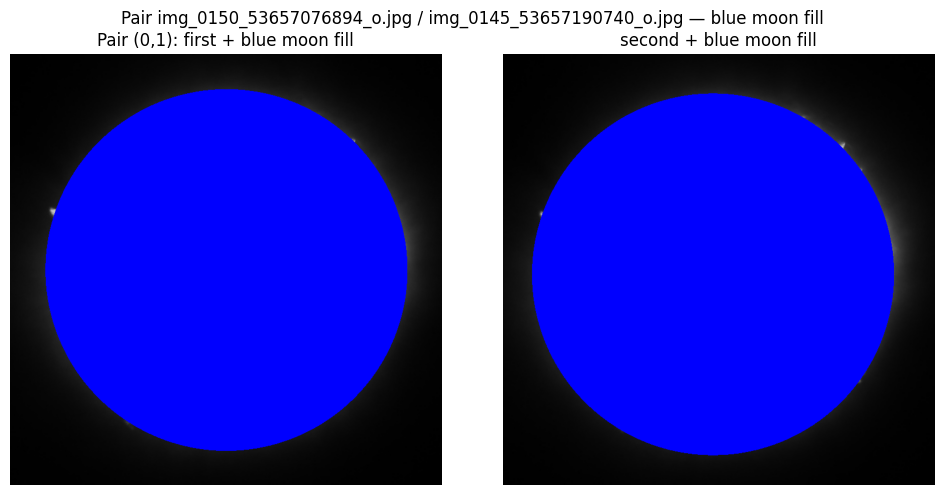

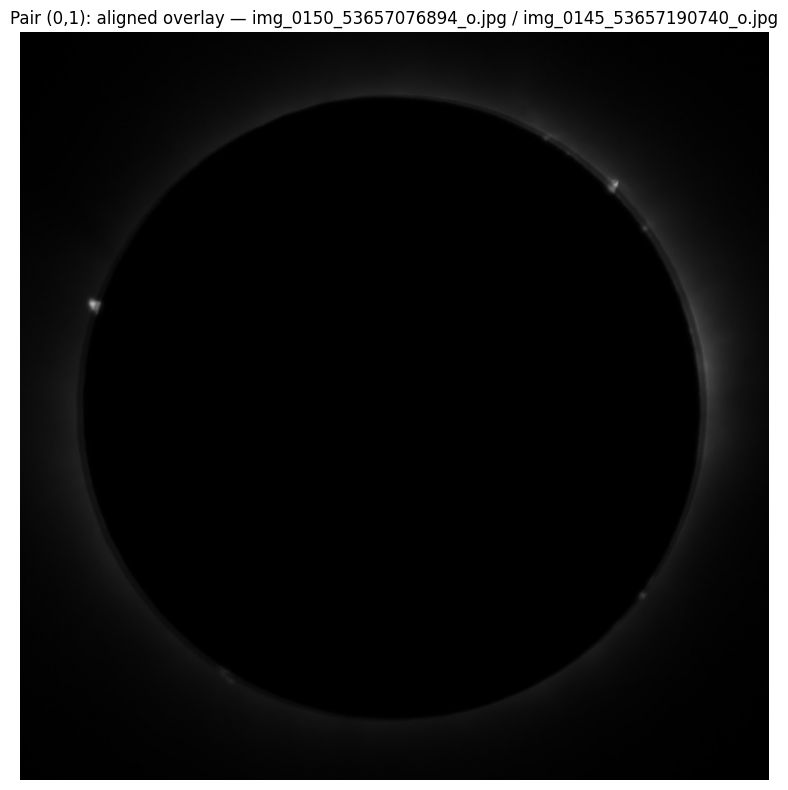

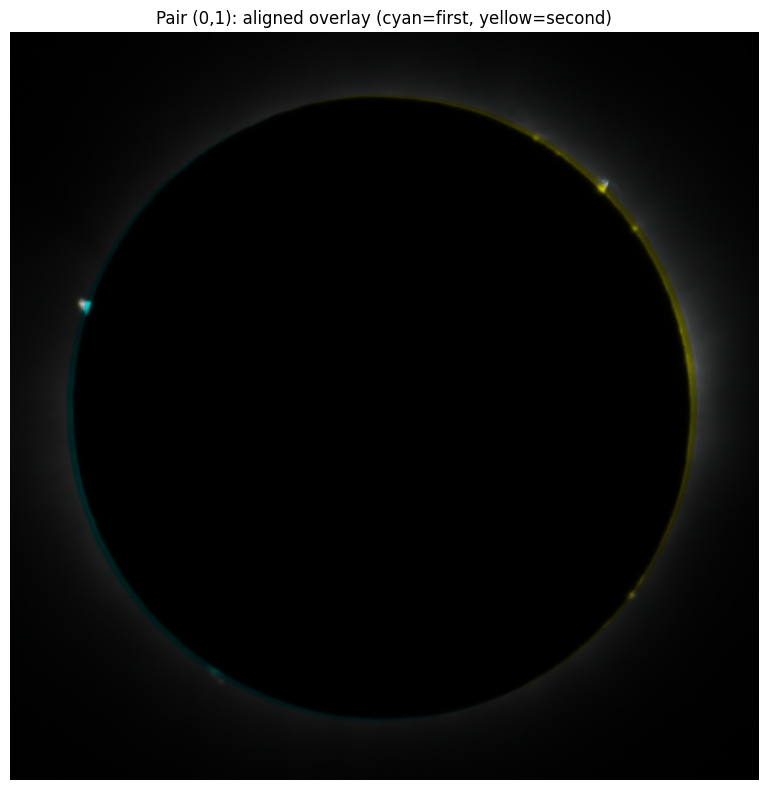

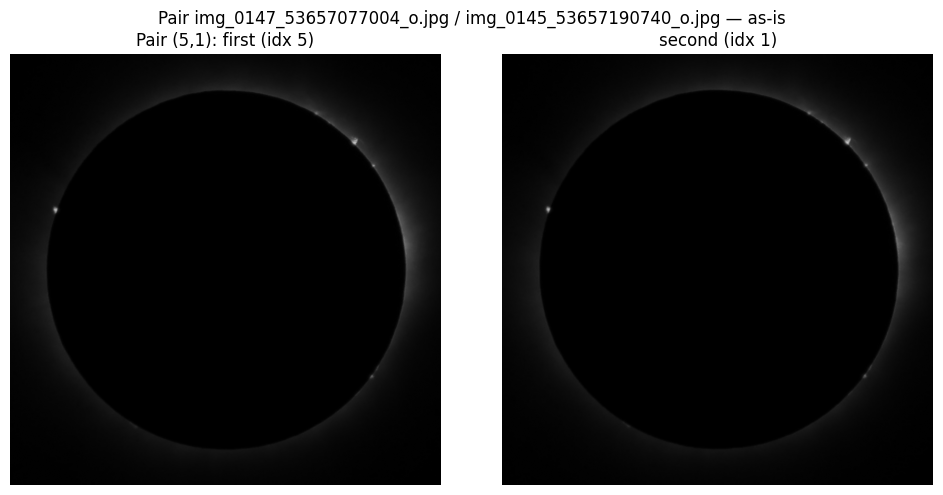

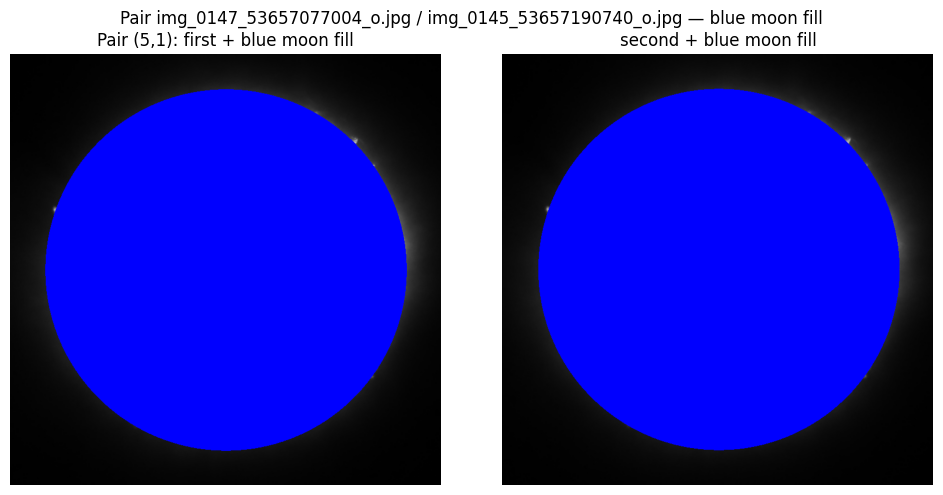

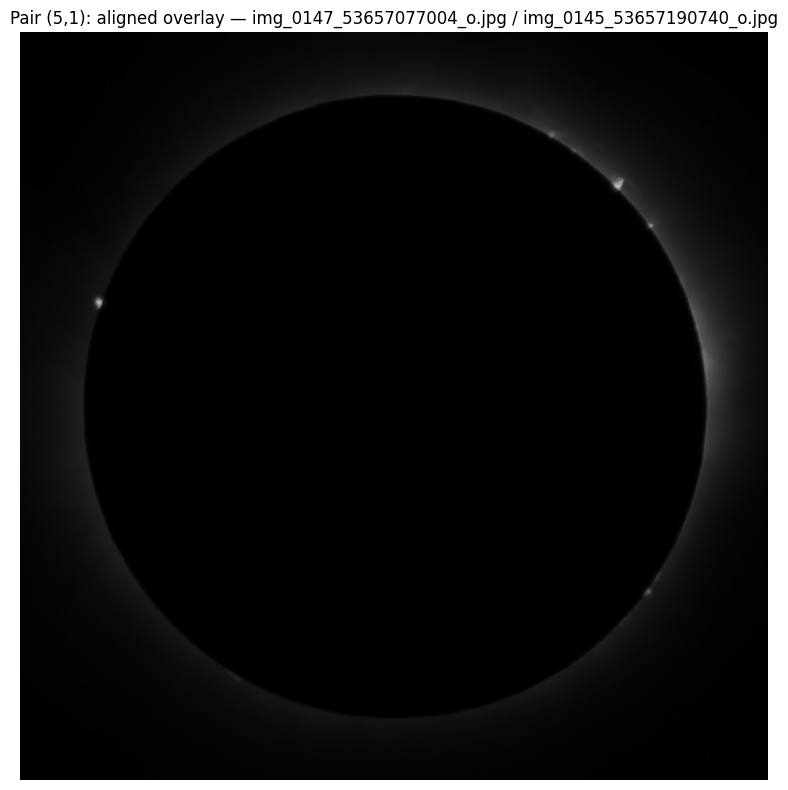

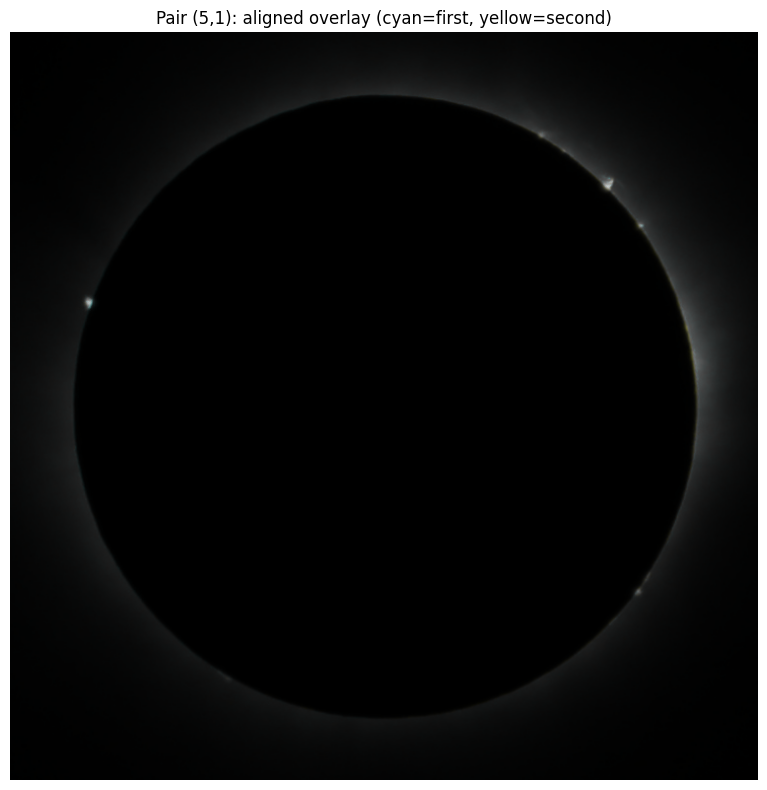

--- Triplet rank 2 (worst first): exp=0.00025, indices (2,4,5), score=0.8660
  A=img_0146_53657190745_o.jpg  B=img_0149_53655849382_o.jpg  C=img_0147_53657077004_o.jpg


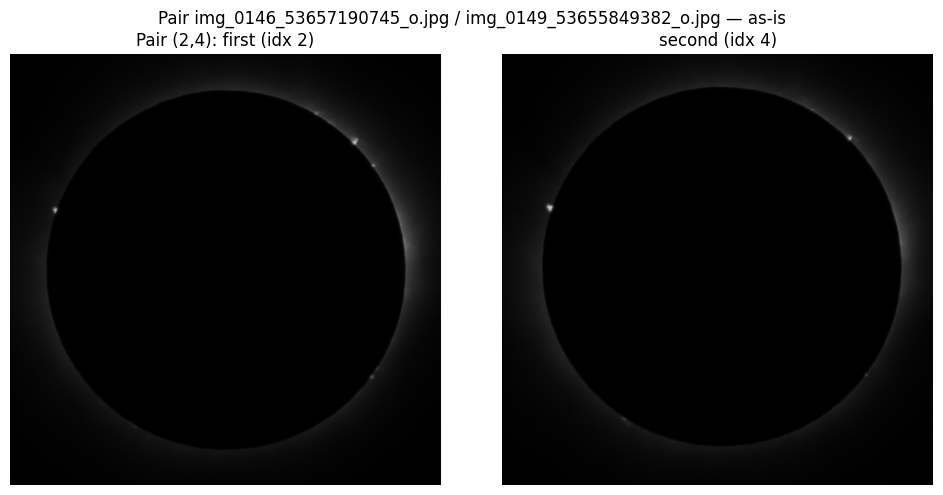

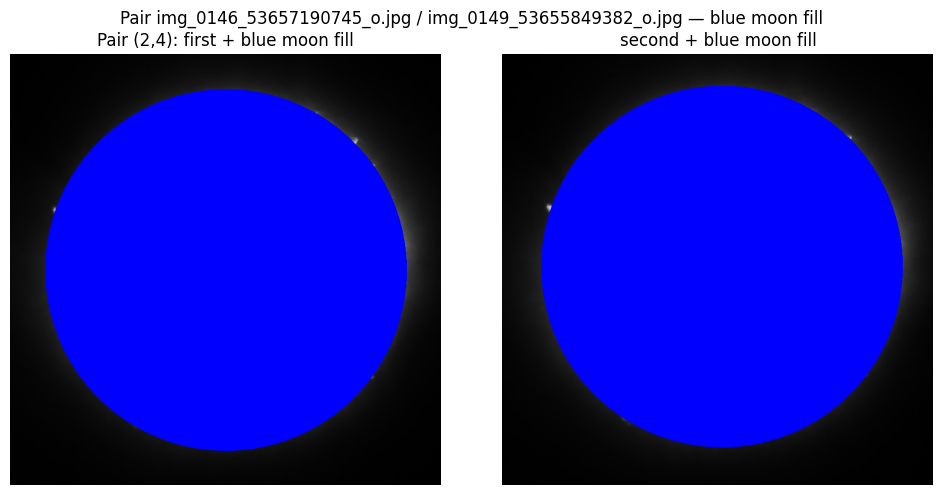

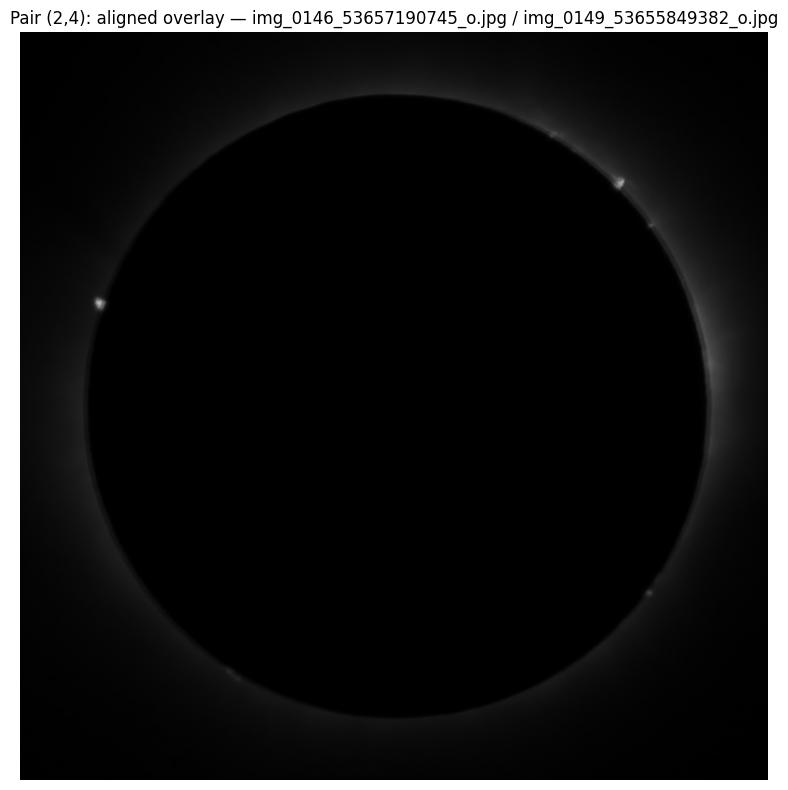

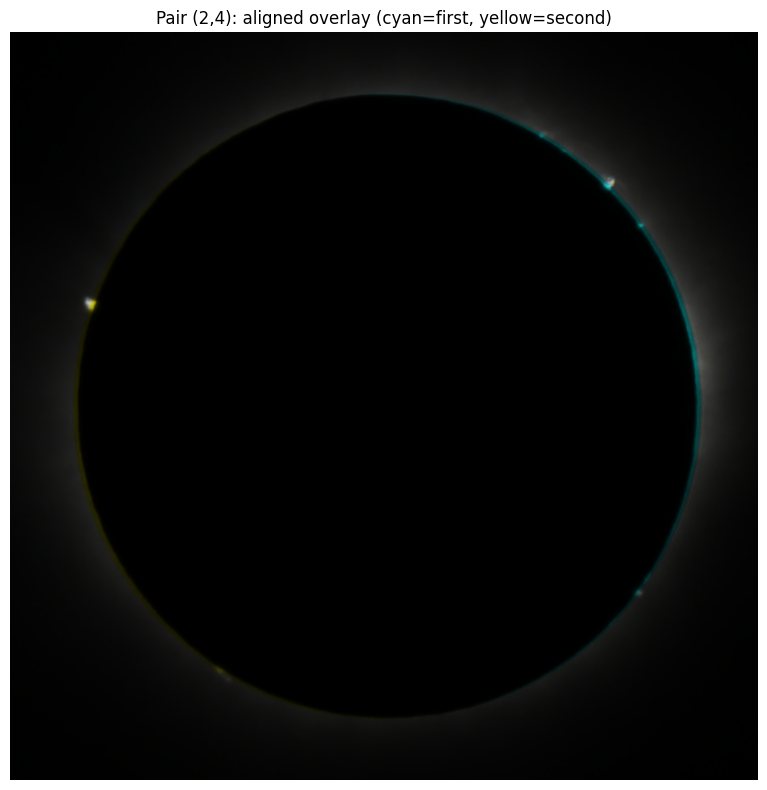

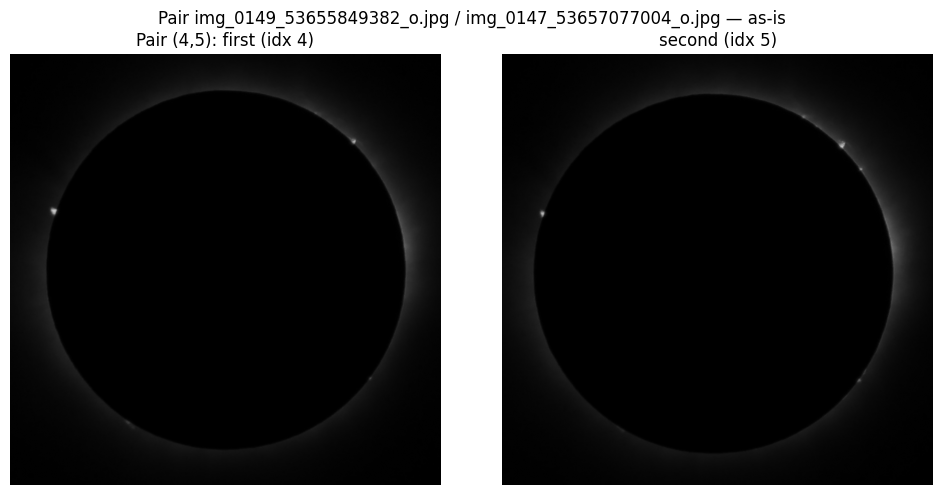

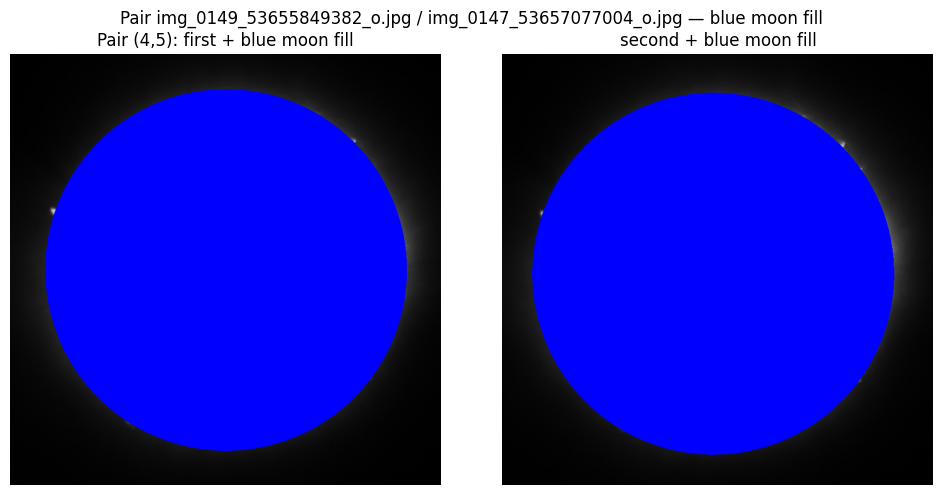

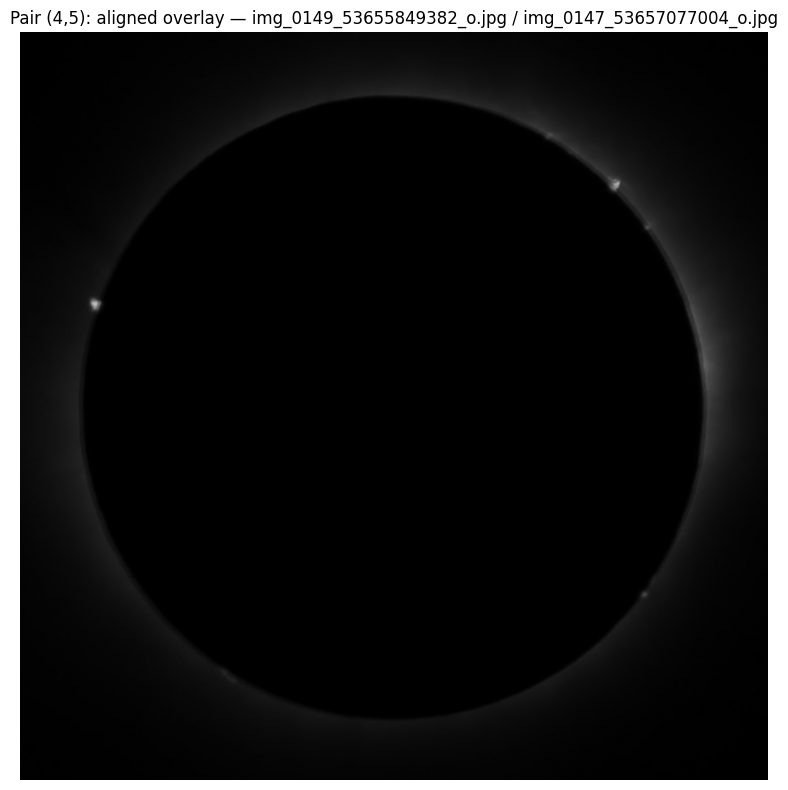

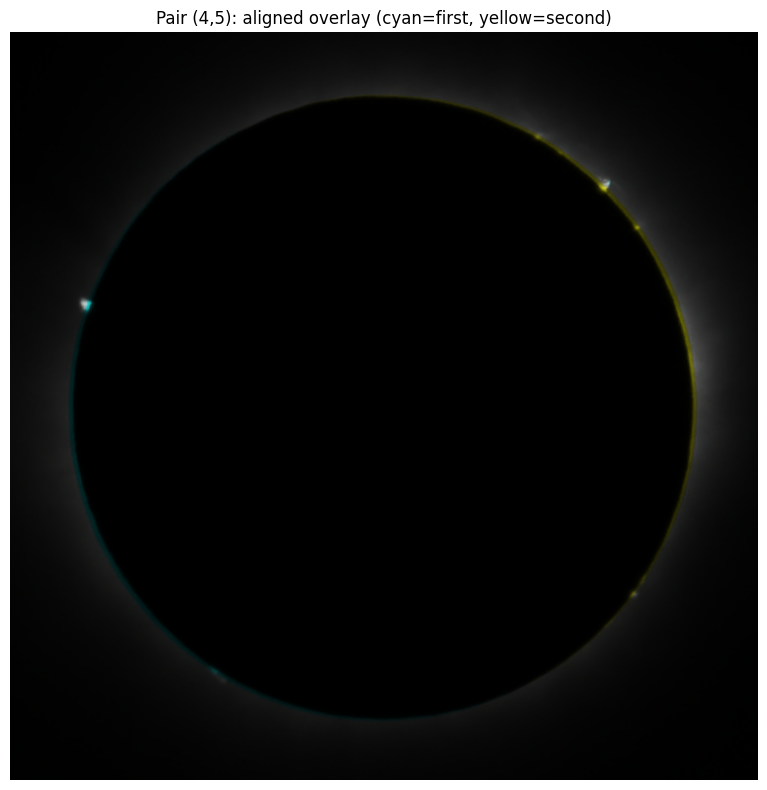

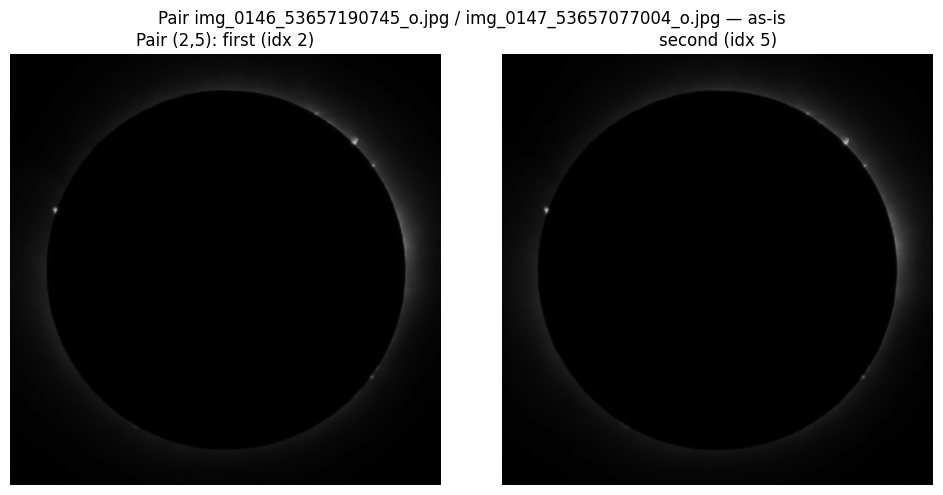

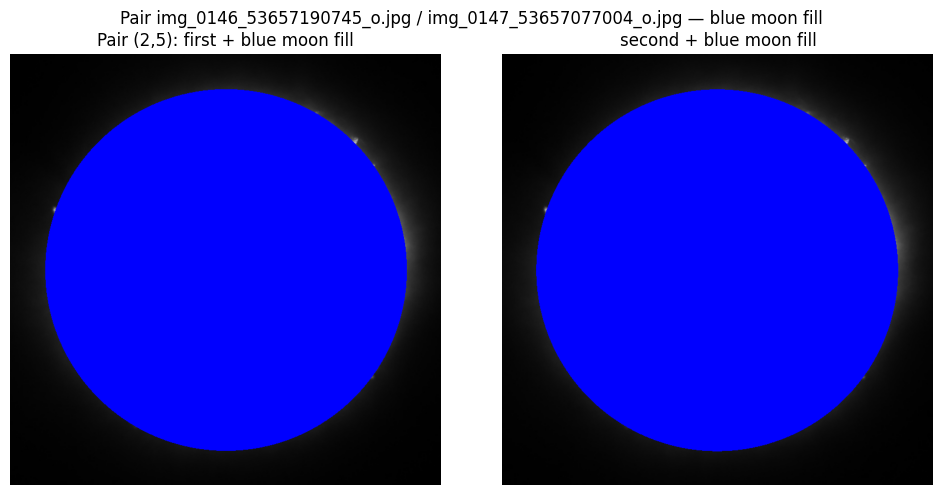

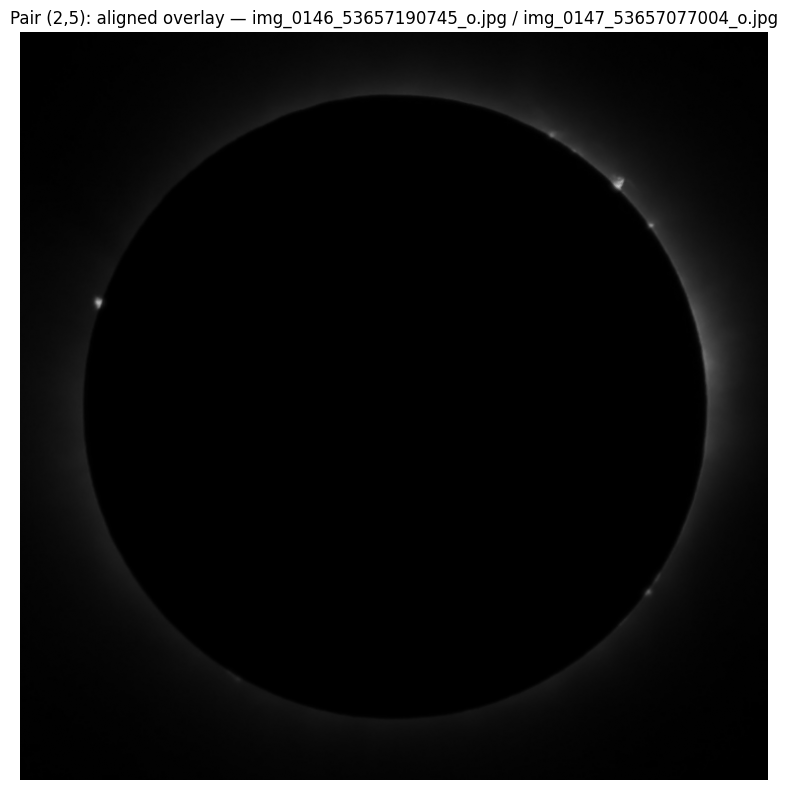

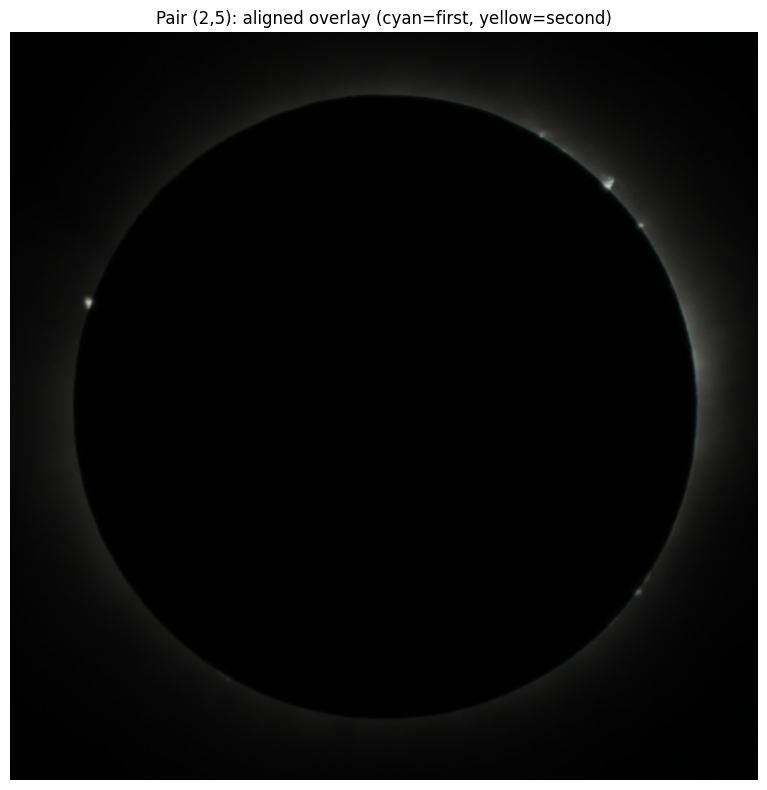

--- Triplet rank 3 (worst first): exp=0.0005, indices (2,6,1), score=0.8562
  A=img_0151_53657190625_o.jpg  B=img_0144_53657077009_o.jpg  C=img_0153_53657190615_o.jpg


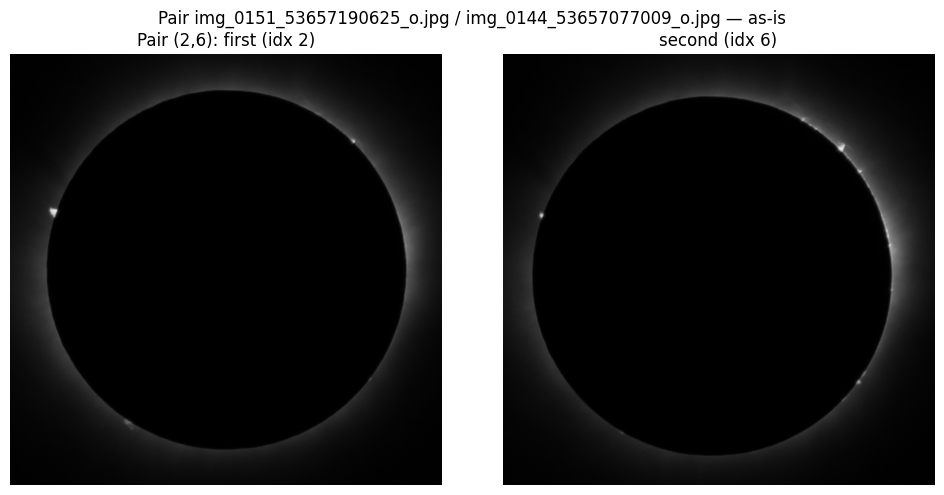

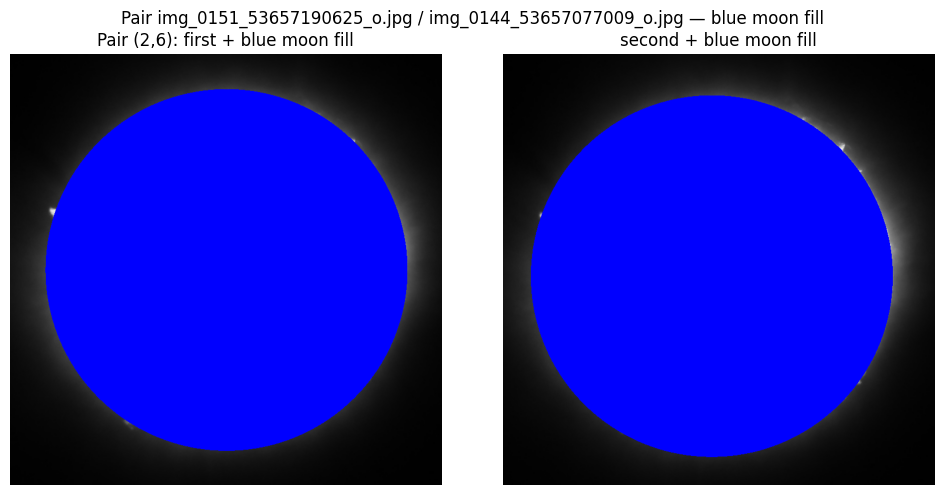

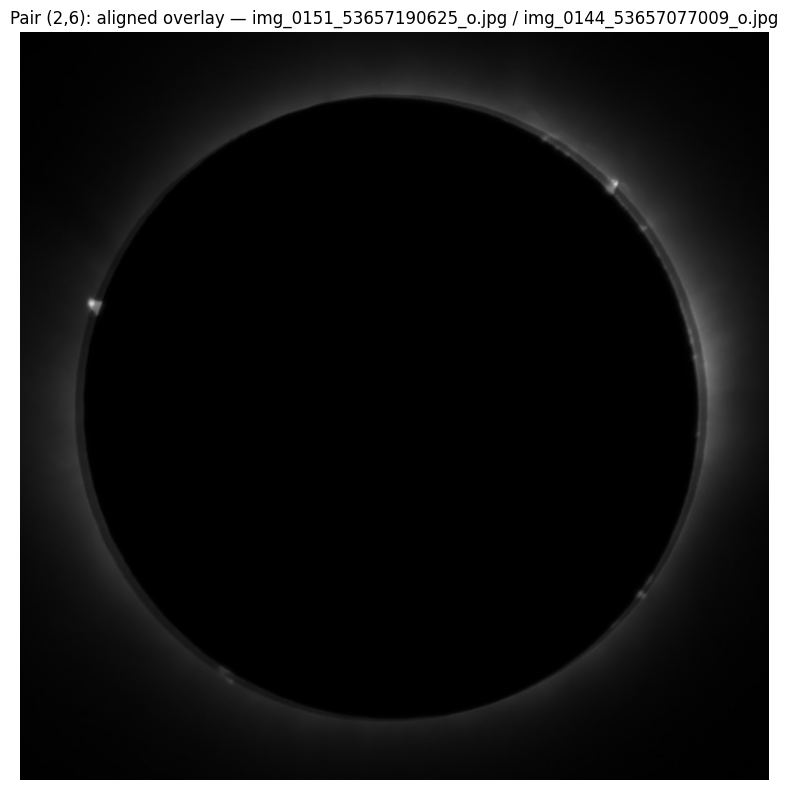

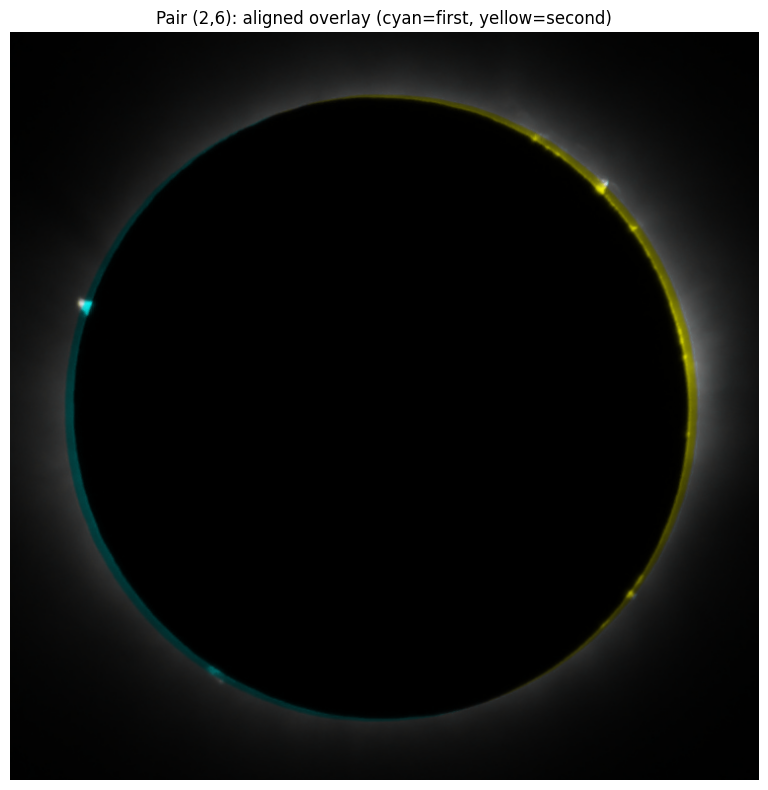

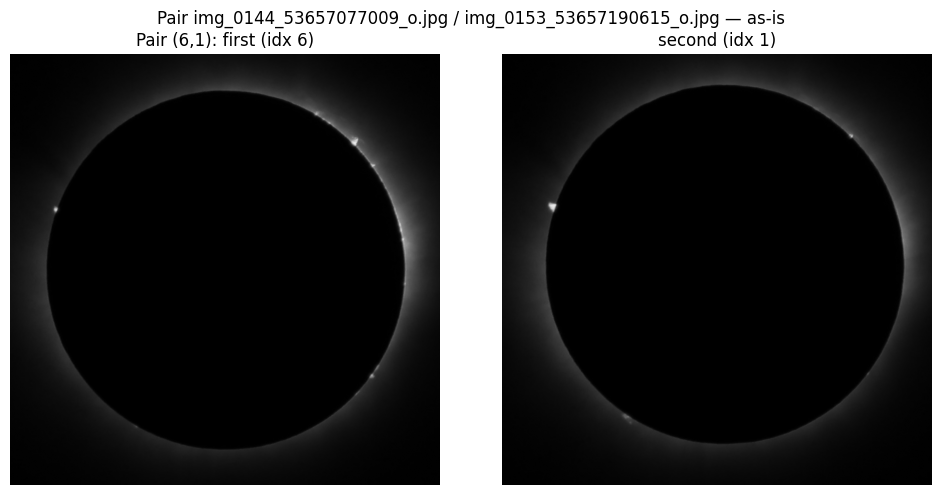

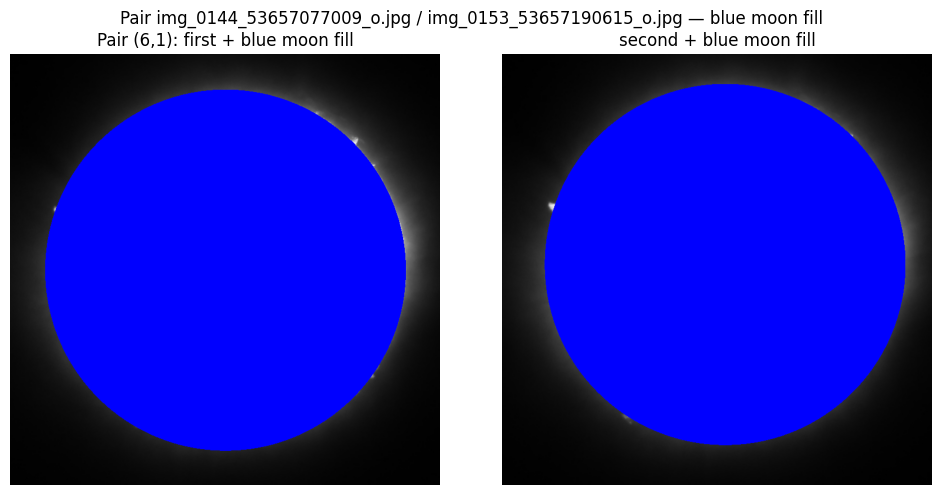

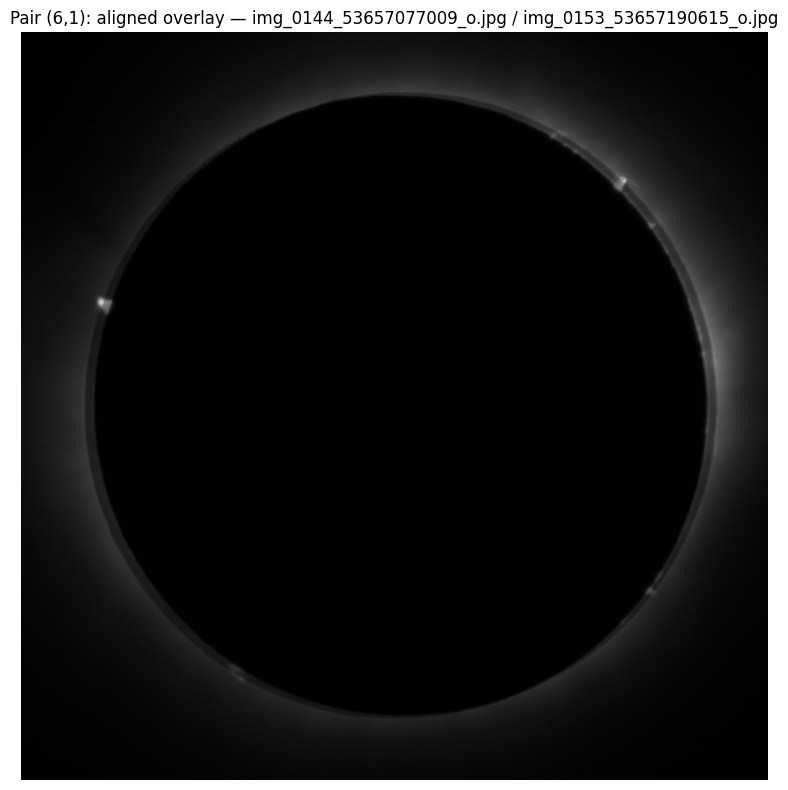

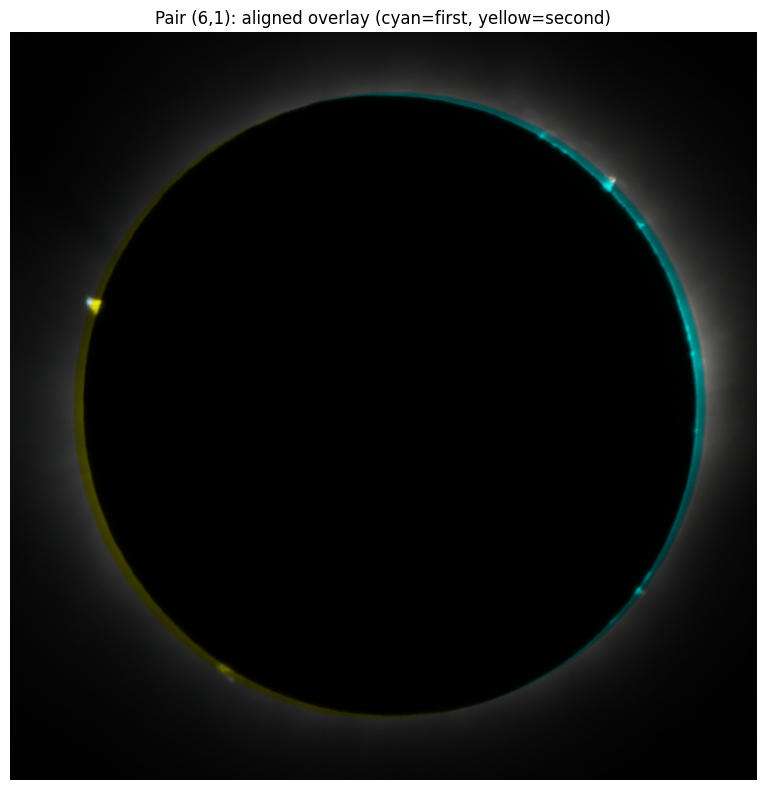

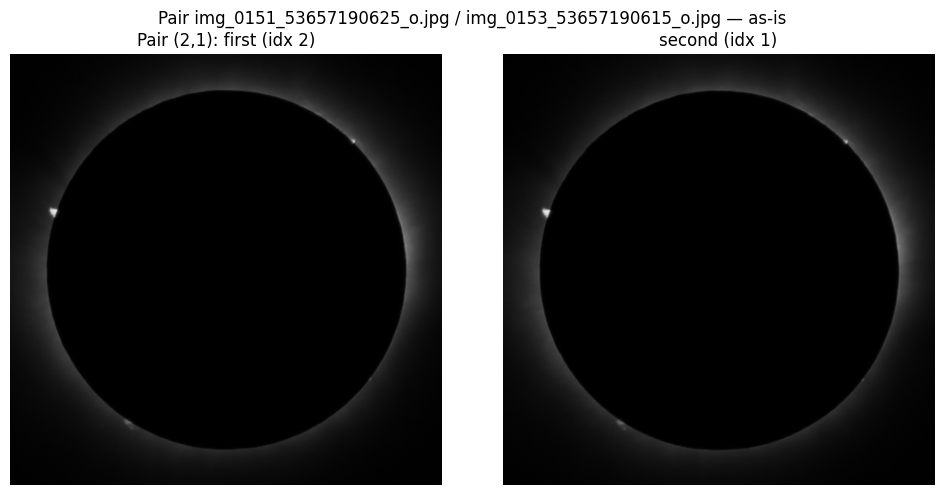

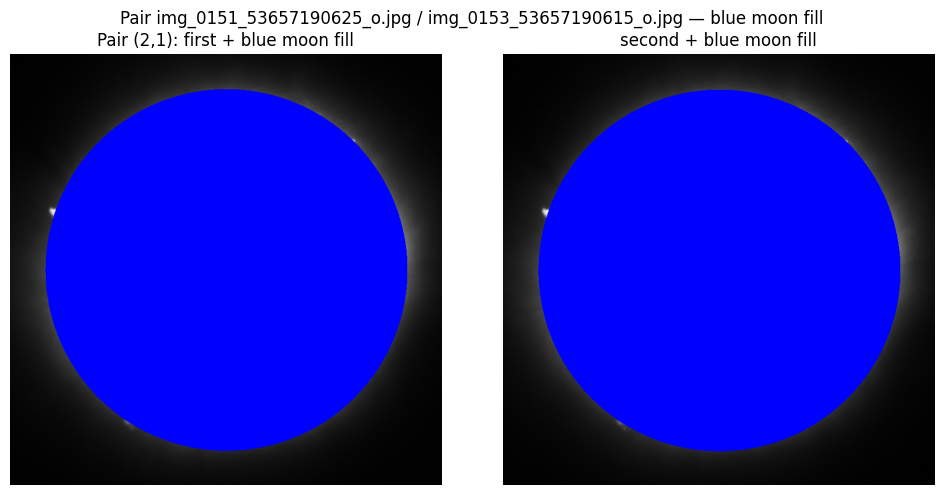

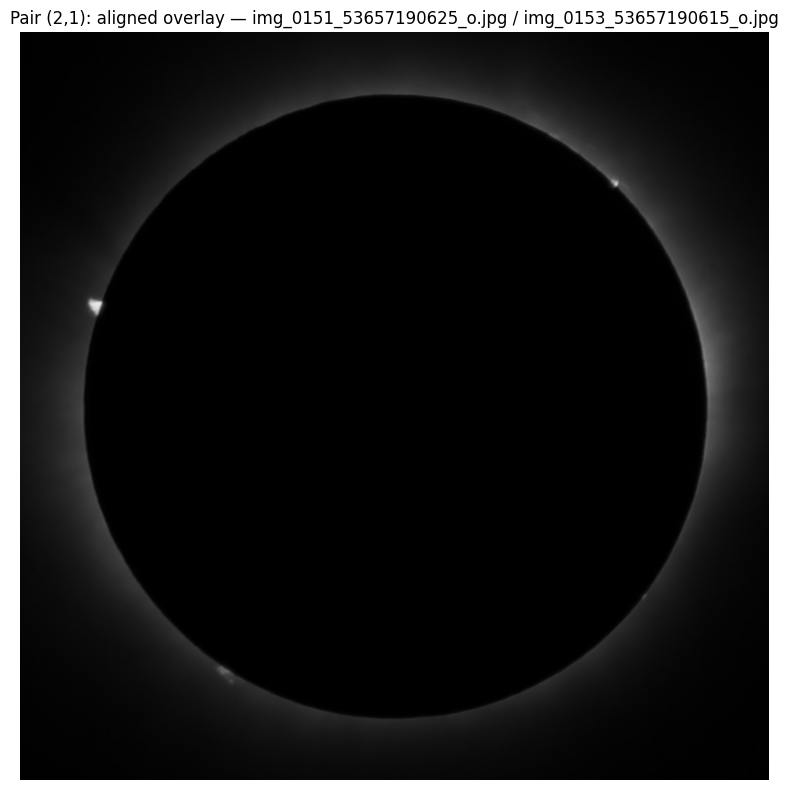

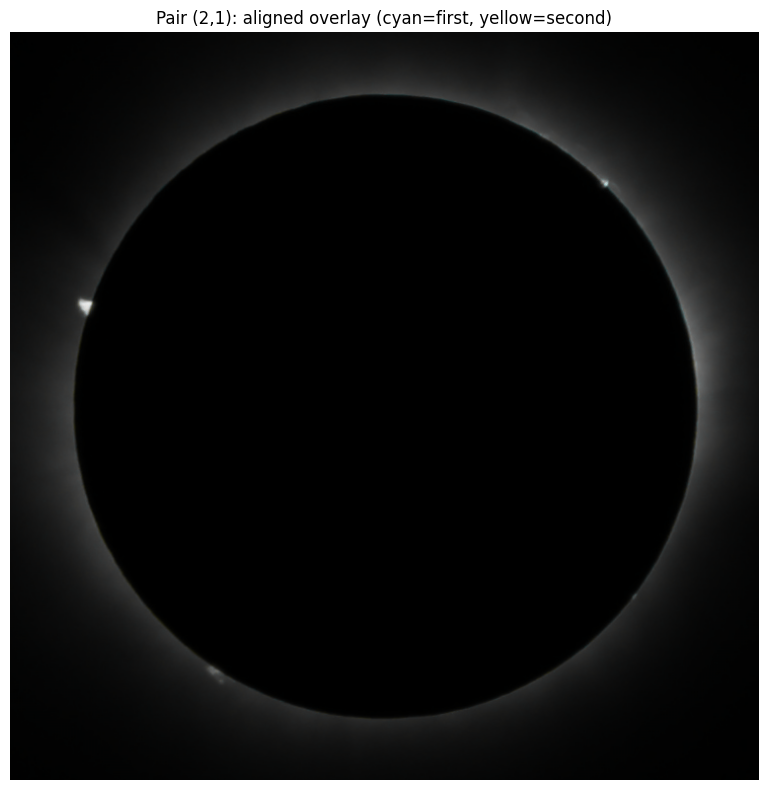

In [6]:
def compose_transforms(s1_i, s1_j, rot1_deg, s2_i, s2_j, rot2_deg):
    """Compose transform (s1, rot1) then (s2, rot2). Returns (s_i, s_j, rot_deg).
    Each transform is (shift_i, shift_j, rotation_deg) mapping frame A -> B for sampling.
    (A->B) composed with (B->C) gives (A->C).
    """
    theta1_rad = math.radians(rot1_deg)
    cos1, sin1 = math.cos(theta1_rad), math.sin(theta1_rad)
    # R(θ1) * (s2_i, s2_j) counterclockwise
    s_rot_i = cos1 * s2_i - sin1 * s2_j
    s_rot_j = sin1 * s2_i + cos1 * s2_j
    return (s1_i + s_rot_i, s1_j + s_rot_j, rot1_deg + rot2_deg)

def load_grayscale_for_debug(ii):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).cuda().to(torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    angle_rad = math.radians(-angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def prune_failed(reg, threshold):
    """
    For each exposure group, if max check-2 discrepancy (A->B)+(B->C) vs (A->C) > threshold,
    iteratively remove the image that appears most often in failing triplets, and drop all
    reg entries involving it. Modifies reg in place.
    """
    reg = copy.deepcopy(reg)
    exposure_times = sorted(list({e for (e, i, j) in reg}))

    for exp_key in exposure_times:
        while True:
            reg_exp = {(i, j): v for (e, i, j), v in reg.items() if e == exp_key}
            indices = {i for (e, i, j) in reg}.union({j for (e, i, j) in reg})
            indices = sorted(list(indices))
            max_disc = 0.0
            bad_triplets = []  # list of (a, b, c, score)

            for a, b, c in itertools.permutations(indices, 3):
                if (a, b) not in reg_exp or (b, c) not in reg_exp or (a, c) not in reg_exp:
                    continue
                rab = reg_exp[(a, b)]
                rbc = reg_exp[(b, c)]
                rac = reg_exp[(a, c)]
                composed = compose_transforms(rab[0], rab[1], rab[2], rbc[0], rbc[1], rbc[2])
                res_i = abs(composed[0] - rac[0])
                res_j = abs(composed[1] - rac[1])
                res_rot = abs(composed[2] - rac[2])
                score = max(res_i, res_j, res_rot)
                if score > max_disc:
                    max_disc = score
                if score > threshold:
                    bad_triplets.append((a, b, c, score))

            if not bad_triplets:
                break

            counts = Counter()
            for (a, b, c, _) in bad_triplets:
                counts[a] += 1
                counts[b] += 1
                counts[c] += 1
            k = counts.most_common(1)[0][0]

            to_remove = [key for key in reg if key[0] == exp_key and (key[1] == k or key[2] == k)]
            for key in to_remove:
                del reg[key]
    return reg

def print_reg(reg):
    """Print per exposure: number of images and number of triplets (sorted by exposure time)."""
    exp_keys = sorted(list({e for (e, i, j) in reg}))
    for exp_key in exp_keys:
        reg_exp = {(i, j): v for (e, i, j), v in reg.items() if e == exp_key}
        indices = set()
        for (i, j) in reg_exp:
            indices.add(i)
            indices.add(j)
        n_images = len(indices)
        n_triplets = 0
        for a, b, c in itertools.combinations(indices, 3):
            if (a, b) in reg_exp and (b, c) in reg_exp and (a, c) in reg_exp:
                n_triplets += 1
        print(f"exp={exp_key:.5f}: images={n_images}, triplets={n_triplets}")

if True:
    # All triplets (within each exposure group), sorted worst to best; debug images for top 3
    device = torch.device("cuda")
    print_reg(reg)
    print('----------------- pruning ------------------')
    reg = prune_failed(reg, 1.0)
    print_reg(reg)
    all_triplets = []
    for exp_key in exposure_groups:
        if abs(exp_key - 1.0) < 1e-9:
            continue
        group = list(exposure_groups[exp_key])
        n = len(group)
        if n < 3:
            continue
        reg_debug = {(i, j): v for (e, i, j), v in reg.items() if e == exp_key}
        for a, b, c in itertools.permutations(range(n), 3):
            rab = reg_debug[(a, b)]
            rbc = reg_debug[(b, c)]
            rac = reg_debug[(a, c)]
            composed = compose_transforms(rab[0], rab[1], rab[2], rbc[0], rbc[1], rbc[2])
            res_i = abs(composed[0] - rac[0])
            res_j = abs(composed[1] - rac[1])
            res_rot = abs(composed[2] - rac[2])
            score = max(res_i, res_j, res_rot)
            all_triplets.append((exp_key, a, b, c, score))
    all_triplets.sort(key=lambda x: -x[4])
    top3_triplets = all_triplets[:3]
    print(f"Total triplets: {len(all_triplets)}, showing debug for top 3 worst.")

    def fill_moon_blue_np(arr, moon_i, moon_j, fill_radius):
        """arr (H,W) or (H,W,3) float [0,1]. Fill moon circle with blue (0,0,1). Returns RGB (H,W,3)."""
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        H, W = arr.shape[0], arr.shape[1]
        y = np.arange(H, dtype=np.float32)[:, None] - moon_i
        x = np.arange(W, dtype=np.float32)[None, :] - moon_j
        r = np.sqrt(x*x + y*y)
        mask = r <= fill_radius
        out = arr.copy()
        out[mask, 0] = 0.0
        out[mask, 1] = 0.0
        out[mask, 2] = 1.0
        return out

    for rank, (exp_key, a, b, c, score) in enumerate(top3_triplets):
        group = list(exposure_groups[exp_key])
        reg_debug = {(i, j): v for (e, i, j), v in reg.items() if e == exp_key}
        print(f"--- Triplet rank {rank+1} (worst first): exp={exp_key}, indices ({a},{b},{c}), score={score:.4f}")
        print(f"  A={group[a].path.name}  B={group[b].path.name}  C={group[c].path.name}")
        pairs = [(a, b), (b, c), (a, c)]
        for (i, j) in pairs:
            ii1, ii2 = group[i], group[j]
            moon1 = ii1.moon
            mi, mj, r = moon1[0], moon1[1], moon1[2]
            half = 1.2 * r
            i_lo = max(0, int(mi - half))
            i_hi = min(ii1.height, int(mi + half))
            j_lo = max(0, int(mj - half))
            j_hi = min(ii1.width, int(mj + half))

            g1 = load_grayscale_for_debug(ii1)
            g2 = load_grayscale_for_debug(ii2)
            shift_i, shift_j, rotation = reg_debug[(i, j)]
            g2_aligned = apply_transform_single(g2, shift_i, shift_j, rotation, device)

            arr1 = g1.cpu().numpy()
            arr2 = g2.cpu().numpy()
            arr2_aligned = g2_aligned.cpu().numpy()

            crop1 = arr1[i_lo:i_hi, j_lo:j_hi]
            crop2 = arr2[i_lo:i_hi, j_lo:j_hi]
            crop2_aligned = arr2_aligned[i_lo:i_hi, j_lo:j_hi]

            # 1) Both images as they are
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            ax1.imshow(crop1, cmap="gray", vmin=0, vmax=1)
            ax1.set_title(f"Pair ({i},{j}): first (idx {i})")
            ax1.axis("off")
            ax2.imshow(crop2, cmap="gray", vmin=0, vmax=1)
            ax2.set_title(f"second (idx {j})")
            ax2.axis("off")
            plt.suptitle(f"Pair {ii1.path.name} / {ii2.path.name} — as-is")
            plt.tight_layout()
            plt.show()

            # 2) Both with fill_moon_circle in blue
            r1, r2 = ii1.moon[2], ii2.moon[2]
            m1_i, m1_j = ii1.moon[0], ii1.moon[1]
            m2_i, m2_j = ii2.moon[0], ii2.moon[1]
            filled1 = fill_moon_blue_np(arr1, m1_i, m1_j, r1 + 2.0)
            filled2 = fill_moon_blue_np(arr2, m2_i, m2_j, r2 + 2.0)
            crop_f1 = filled1[i_lo:i_hi, j_lo:j_hi]
            crop_f2 = filled2[i_lo:i_hi, j_lo:j_hi]
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            ax1.imshow(crop_f1)
            ax1.set_title(f"Pair ({i},{j}): first + blue moon fill")
            ax1.axis("off")
            ax2.imshow(crop_f2)
            ax2.set_title(f"second + blue moon fill")
            ax2.axis("off")
            plt.suptitle(f"Pair {ii1.path.name} / {ii2.path.name} — blue moon fill")
            plt.tight_layout()
            plt.show()

            # 3) Aligned and semitransparent (0.5 * first + 0.5 * aligned second)
            blended = 0.5 * crop1.astype(np.float64) + 0.5 * crop2_aligned.astype(np.float64)
            plt.figure(figsize=(8, 8))
            plt.imshow(blended, cmap="gray", vmin=0, vmax=1)
            plt.title(f"Pair ({i},{j}): aligned overlay — {ii1.path.name} / {ii2.path.name}")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

            # Same overlay in color: first = cyan, second = yellow
            c1 = np.clip(crop1.astype(np.float64), 0, 1)
            c2 = np.clip(crop2_aligned.astype(np.float64), 0, 1)
            rgb = np.zeros((*c1.shape, 3), dtype=np.float64)
            rgb[..., 0] = c2
            rgb[..., 1] = np.maximum(c1, c2)
            rgb[..., 2] = c1
            plt.figure(figsize=(8, 8))
            plt.imshow(rgb)
            plt.title(f"Pair ({i},{j}): aligned overlay (cyan=first, yellow=second)")
            plt.axis("off")
            plt.tight_layout()
            plt.show()